# Manual EDA and checks

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [75]:
calib_data = pd.read_excel('results/calibration_data.xlsx')

In [76]:
calib_data

,behavior,dataset,feature,feature mean,feature std
0,traveling,Theoretical (10 fish),phi_trans,1.0000,0.0000
1,traveling,Synthetic dataset,phi_trans,0.9562,0.0222
2,traveling,Real dataset,phi_trans,0.8595,0.0776
3,traveling,Theoretical (10 fish),phi_tan,0.6370,0.0970
4,traveling,Synthetic dataset,phi_tan,0.6605,0.0410
5,traveling,Real dataset,phi_tan,0.5840,0.0735
6,traveling,Theoretical (10 fish),phi_rad,0.0000,0.2240
7,traveling,Synthetic dataset,phi_rad,0.0367,0.0578
8,traveling,Real dataset,phi_rad,0.0528,0.0931
9,milling,Theoretical (10 fish),phi_trans,0.2820,0.1430


In [77]:
feature_order = ['phi_trans','phi_tan','phi_rad']
hue_order = ['Theoretical (10 fish)','Synthetic dataset','Real dataset']
feature_labels = {
    "phi_trans": r"$\Phi_{\mathrm{trans}}$",
    "phi_tan":   r"$\Phi_{\mathrm{tan}}$",
    "phi_rad":   r"$\Phi_{\mathrm{rad}}^{\pm}$",
}

In [78]:
behavior_order = calib_data["behavior"].drop_duplicates().tolist()
colors = ['#8BA8C9','#E3B15E','#6A898C']

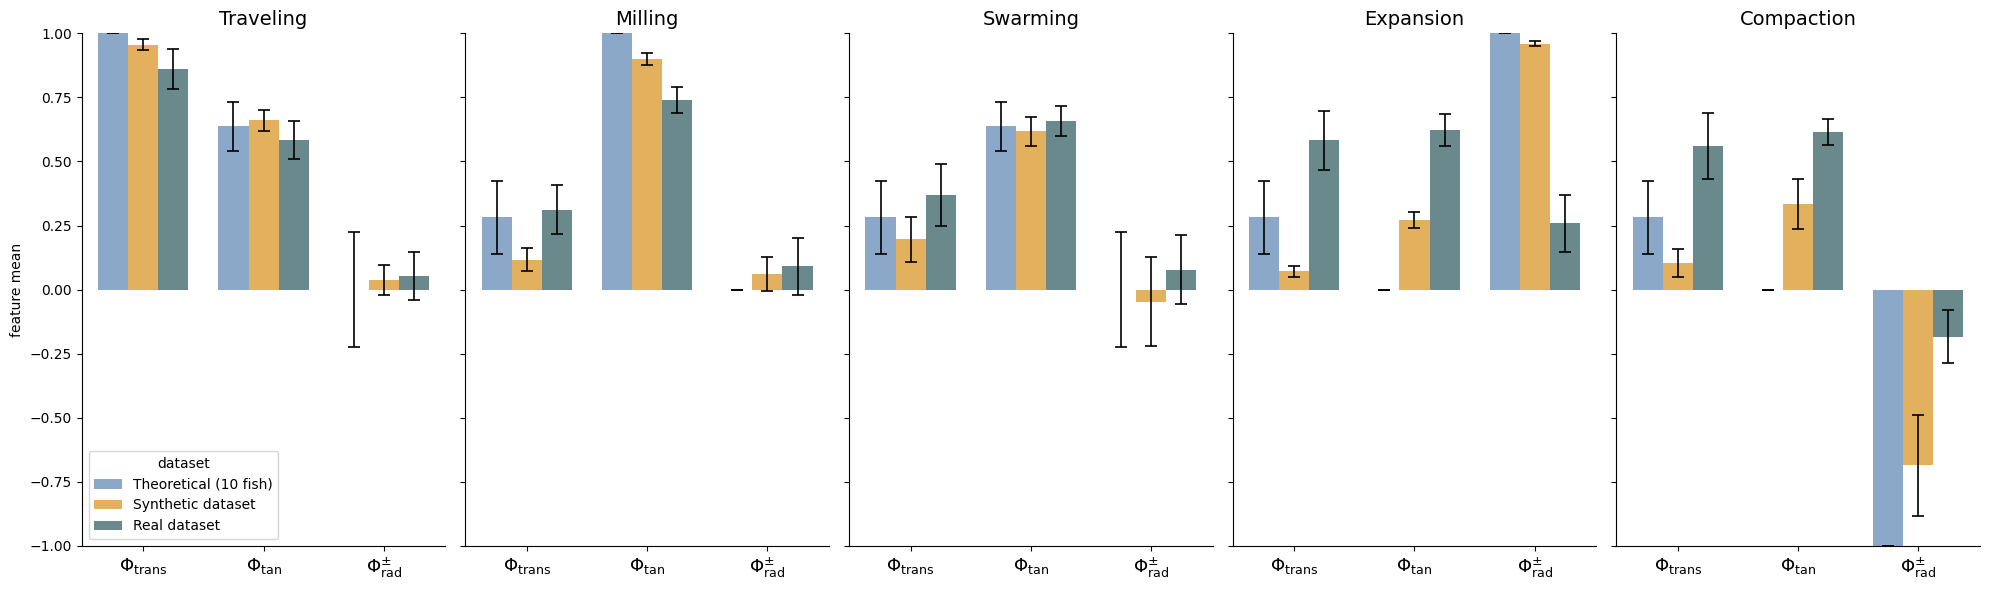

In [79]:
fig, axes = plt.subplots(
    1,
    len(behavior_order),
    figsize=(4 * len(behavior_order), 6),
    sharey=True
)

# Makes sure axes is always iterable even if there is only one subplot
axes = np.atleast_1d(axes)

def plot_behavior(behavior: str, axis_id: int):

    ax = axes[axis_id]

    # Filter dataframe
    d = calib_data[calib_data["behavior"] == behavior].copy()

    # X positions of the three features
    x = np.arange(len(feature_order))

    # Width of each individual bar
    width = 0.25

    # Offsets for hue:
    # dataset 1 -> left
    # dataset 2 -> center
    # dataset 3 -> right
    offsets = (
        np.arange(len(hue_order))
        - (len(hue_order) - 1) / 2
    ) * width

    # -----------------------------------------------------
    # Draw each dataset separately
    # -----------------------------------------------------

    for i, dataset in enumerate(hue_order):

        sub = (
            d[d["dataset"] == dataset]
            .set_index("feature")
            .reindex(feature_order)
        )

        means = sub["feature mean"].to_numpy(dtype=float)
        stds = sub["feature std"].to_numpy(dtype=float)

        positions = x + offsets[i]

        # Handle missing combinations safely
        valid = ~np.isnan(means)

        ax.bar(
            positions[valid],
            means[valid],
            width=width,
            yerr=stds[valid],
            capsize=4,
            color=colors[i],
            label=dataset,
            error_kw={
                "elinewidth": 1.2,
                "capthick": 1.2
            }
        )

    # -----------------------------------------------------
    # Axis formatting
    # -----------------------------------------------------

    ax.set_xticks(x)
    ax.set_xticklabels(
        [feature_labels[f] for f in feature_order],
        fontsize=13
    )

    ax.set_title(
        behavior.capitalize(),
        fontsize=14
    )

    ax.set_xlabel("")

    # Only first subplot gets ylabel
    if axis_id == 0:
        ax.set_ylabel("feature mean")
    else:
        ax.set_ylabel("")

    # Your features appear to be bounded around 0–1
    ax.set_ylim(-1., 1.)

    # Only show legend in first subplot
    if axis_id == 0:
        ax.legend(
            title="dataset",
            frameon=True
        )


# ---------------------------------------------------------
# Plot all behaviors
# ---------------------------------------------------------

for axis_id, behavior in enumerate(behavior_order):
    plot_behavior(
        behavior=behavior,
        axis_id=axis_id
    )


# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

sns.despine()

plt.tight_layout()

plt.show()
